<a href="https://colab.research.google.com/github/Fei-Q/dsst389/blob/main/nb/notebook12a.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Notebook12a

### Setup

Run all of the following before starting the notebook.

In [1]:
! wget -q -nc https://raw.githubusercontent.com/taylor-arnold/fds-py/refs/heads/main/funs.py

In [2]:
import numpy as np
import polars as pl

from funs import *
from plotnine import *
from polars import col as c
theme_set(theme_minimal())
pl.Config(tbl_rows=25)

ub = "https://raw.githubusercontent.com/taylor-arnold/fds-py-nb/refs/heads/main/"

In [3]:
metro = pl.read_csv(ub + "data/acs_cbsa.csv")
wiki = pl.read_csv(ub + "data/wiki_uk_meta.csv.gz", ignore_errors=True)
anno = pl.read_csv(ub + "data/wiki_uk_authors_anno.csv.gz", ignore_errors=True)

In [7]:
metro.head()

name,geoid,quad,lon,lat,pop,density,age_median,hh_income_median,percent_own,rent_1br_median,rent_perc_income,division
str,i64,str,f64,f64,f64,f64,f64,i64,f64,i64,f64,str
"""New York""",35620,"""NE""",-74.101056,40.76877,20.011812,1051.306467,42.9,86445,55.3,1430,31.0,"""Middle Atlantic"""
"""Los Angeles""",31080,"""W""",-118.148722,34.219406,13.202558,1040.647281,41.6,81652,51.3,1468,33.6,"""Pacific"""
"""Chicago""",16980,"""NC""",-87.95882,41.700605,9.607711,508.629406,41.9,78790,68.9,1060,29.0,"""East North Central"""
"""Dallas""",19100,"""S""",-96.970508,32.84948,7.54334,323.181404,41.3,76916,64.1,1106,29.1,"""West South Central"""
"""Houston""",26420,"""S""",-95.401574,29.787083,7.048954,316.543514,41.0,72551,65.1,997,30.0,"""West South Central"""


### Part I: Metro Regions Dimensionality Reduction

1. Apply PCA (principal component analysis) to the `metro` dataset using the following features: density, median age, median household income, percent own, 1BR median rent, and rent as a percentage of income. Use the `.predict(full=True)` method to get the full dataset back with the new components. Then, create a scatter plot of the first two principal components (`dr0` and `dr1`) using text labels with the `name` column so we can see which metro regions are similar to one another. You may want to make the labels smaller to help read them.

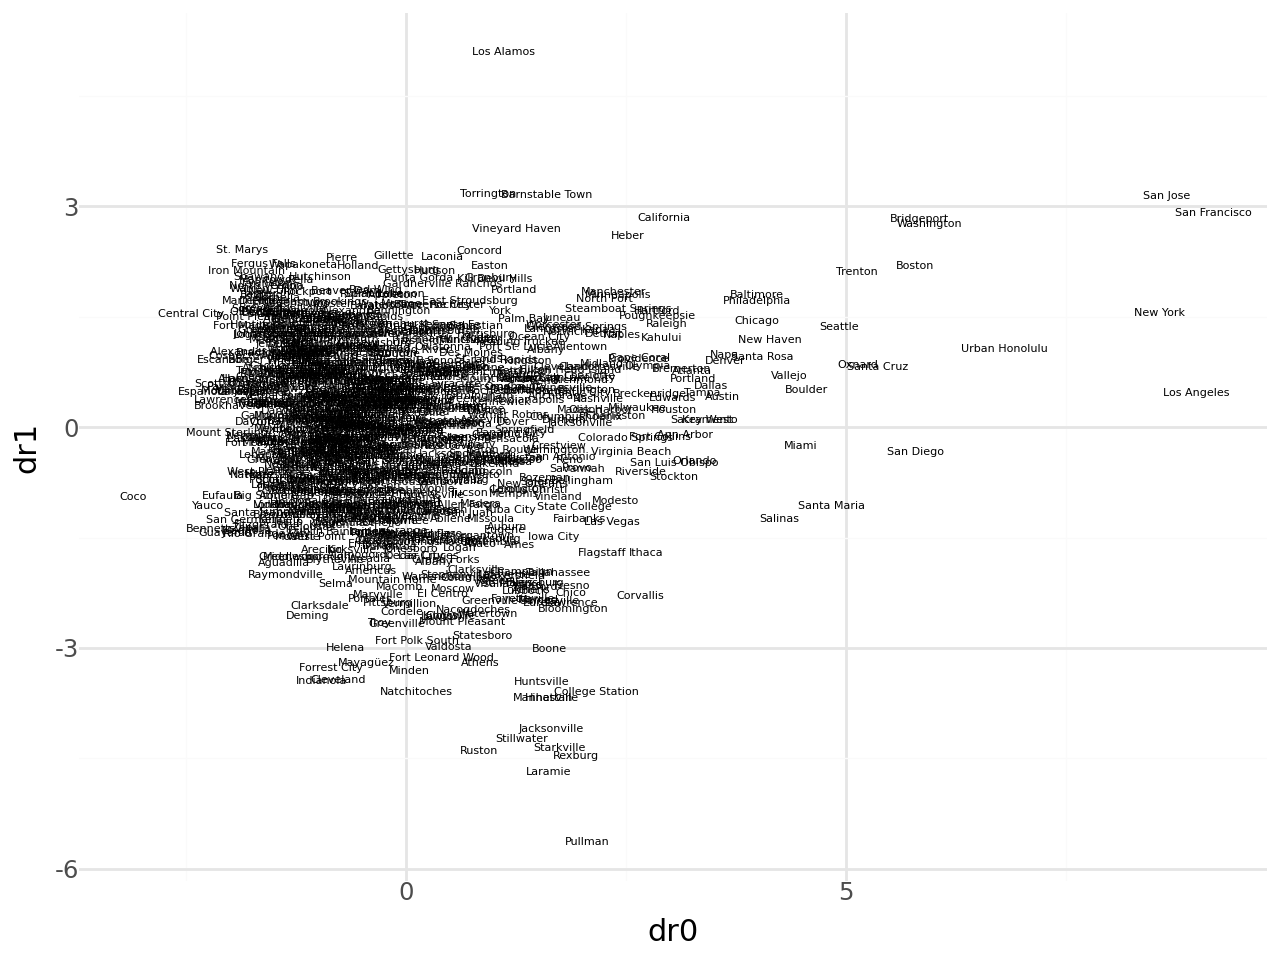

In [4]:
(
    metro
    .pipe(
        DSSklearn.pca,
        features=[c.density, c.age_median, c.hh_income_median,
                  c.percent_own, c.rent_1br_median, c.rent_perc_income]
    )
    .predict(full=True)
    .pipe(ggplot, aes("dr0", "dr1"))
    + geom_text(aes(label = "name"), size=4)
)

2a. Now, we will try two alternative dimensionality reduction techniques on the same set of features: UMAP and t-SNE. Start with UMAP. Create a scatter plot of the first two components. Compare the results visually to the PCA plot above. Notice how UMAP and t-SNE tend to create more distinct clusters while PCA preserves more of the global structure.

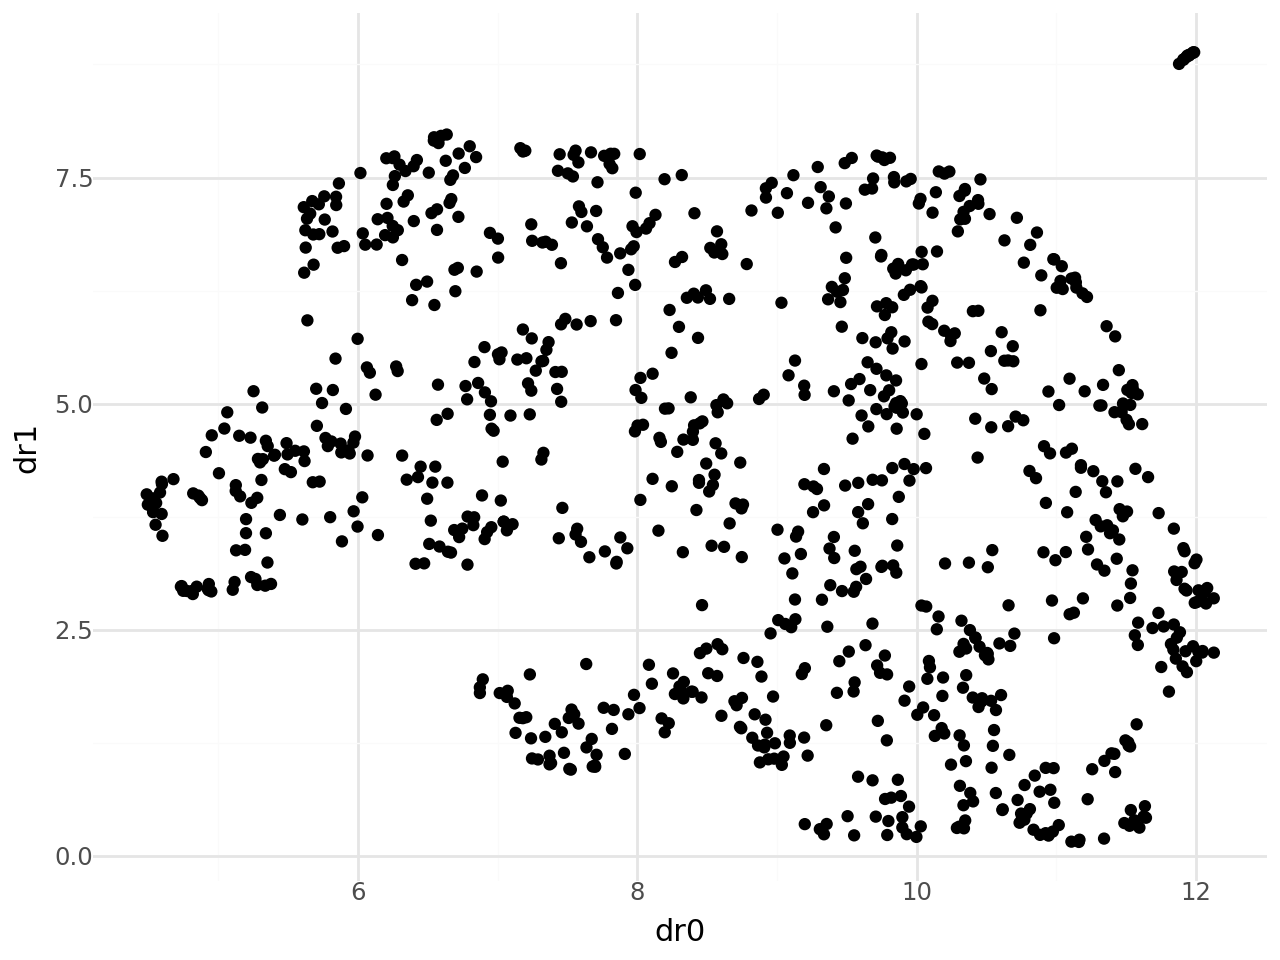

In [5]:
(
    metro
    .pipe(
        DSSklearn.umap,
        features=[c.density, c.age_median, c.hh_income_median,
                  c.percent_own, c.rent_1br_median, c.rent_perc_income]
    )
    .predict(full=True)
    .pipe(ggplot, aes("dr0", "dr1"))
    + geom_point()
)

2b. Now, try t-SNE.

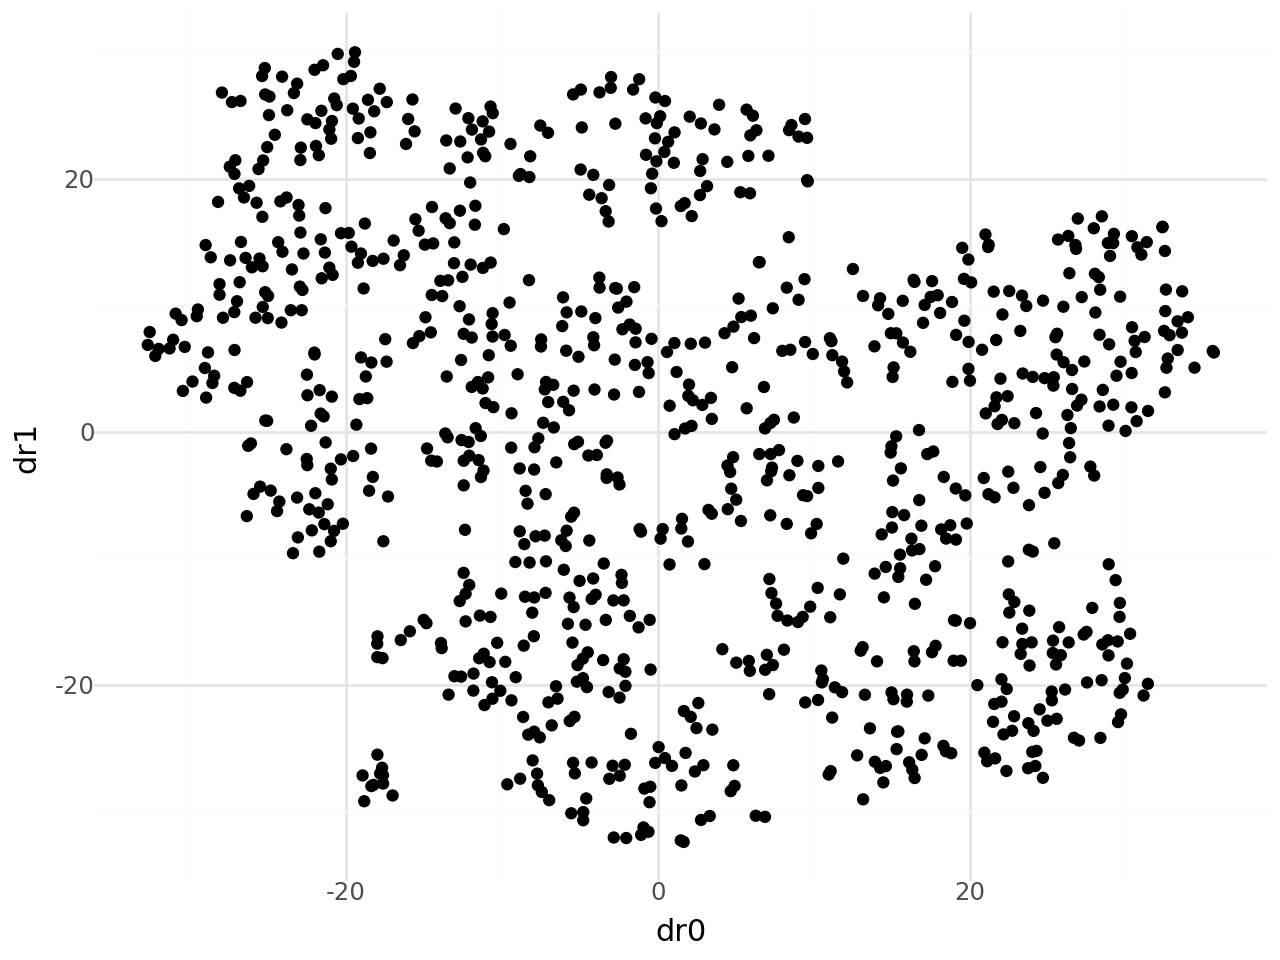

In [6]:
(
    metro
    .pipe(
        DSSklearn.tsne,
        features=[c.density, c.age_median, c.hh_income_median,
                  c.percent_own, c.rent_1br_median, c.rent_perc_income]
    )
    .predict(full=True)
    .pipe(ggplot, aes("dr0", "dr1"))
    + geom_point()
)

### Part II: Metro Regions Clustering

3. Now let's try clustering the metro regions. Use K-Means clustering on the same six features from Part I, setting the number of clusters to 20. Save the result with full predictions as `metro_pca`.

In [8]:
metro_pca = (
    metro
    .pipe(
        DSSklearn.kmeans,
        features=[c.density, c.age_median, c.hh_income_median,
                  c.percent_own, c.rent_1br_median, c.rent_perc_income],
        n_clusters=20
    )
    .predict(full=True)
)

4. For each cluster label, display the names of the top 10 most populous metro regions (sorted by population in descending order). Look through the groupings and see if the clusters seem to be capturing meaningful similarities between regions.

In [9]:
(
    metro_pca
    .sort(c.pop, descending=True)
    .group_by(c.label_)
    .agg(
        regions = c.name.head(10).str.join(",")
    )
    .sort(c.label_)
)

label_,regions
i64,str
0,"""St. Louis,Pittsburgh,Cincinnat…"
1,"""Oklahoma City,Grand Rapids,Oma…"
2,"""Memphis,New Orleans,Tucson,Alb…"
3,"""Tulsa,Wichita,Fayetteville,Ama…"
4,"""Washington,Seattle,San Diego,S…"
5,"""Youngstown,Ocala,Charleston,Bi…"
6,"""North Port,Deltona,Palm Bay,Po…"
7,"""Fayetteville,Killeen,Clarksvil…"
8,"""New York,Los Angeles,Chicago,P…"


5. Visualize the clustering results by applying PCA to the same six features on the `metro_pca` data. Create a scatter plot of the first two principal components, coloring the points by their cluster label. This lets us see how well the K-Means clusters correspond to the structure found by PCA.

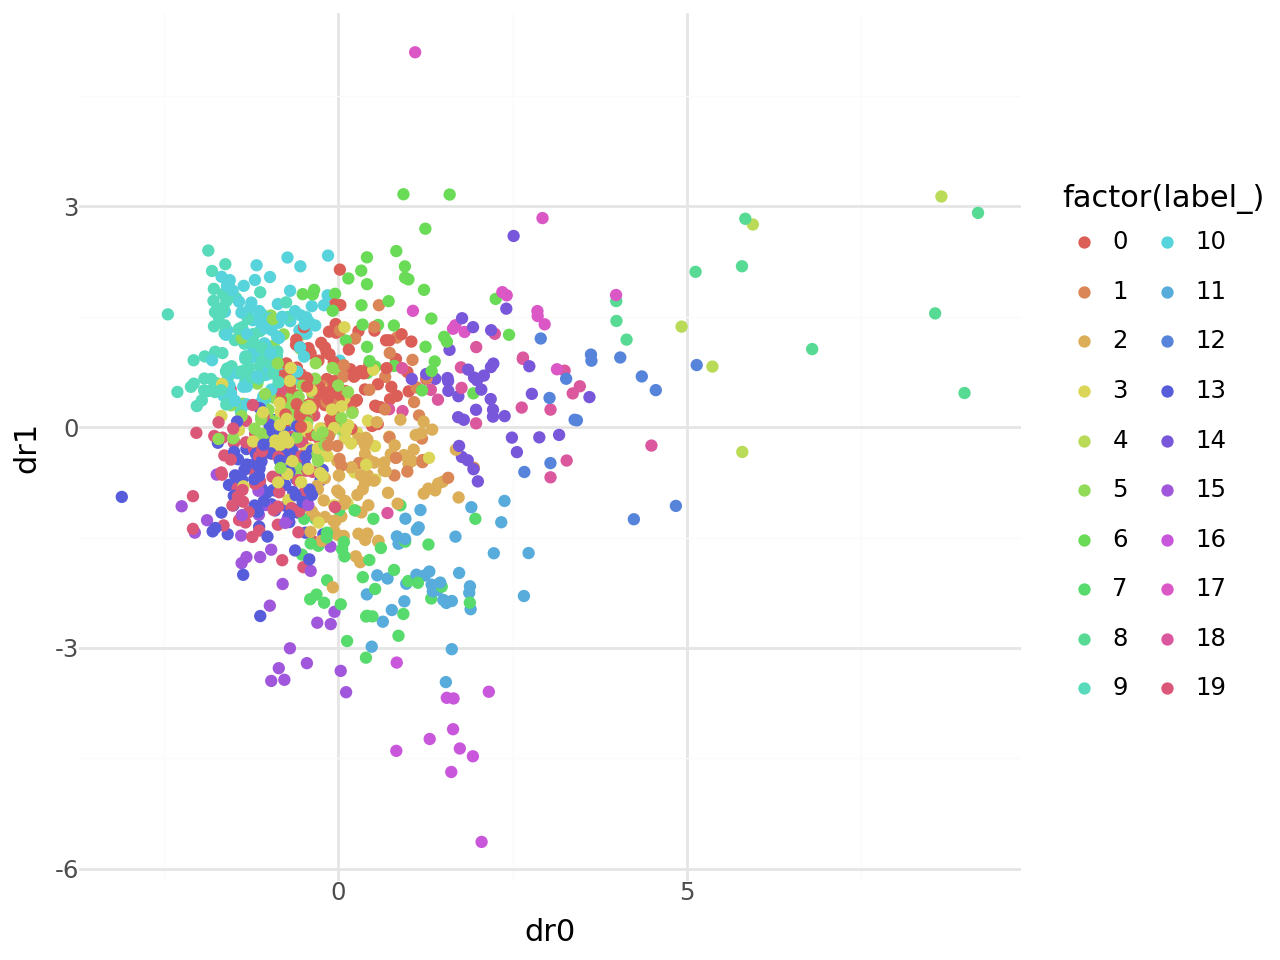

In [10]:
(
    metro_pca
    .pipe(
        DSSklearn.pca,
        features=[c.density, c.age_median, c.hh_income_median,
                  c.percent_own, c.rent_1br_median, c.rent_perc_income]
    )
    .predict(full=True)
    .pipe(ggplot, aes("dr0", "dr1"))
    + geom_point(aes(color="factor(label_)"))
)

6. Compute the mean of each of the six features grouped by cluster label. This gives us a profile of each cluster and helps us interpret what makes regions in the same cluster similar.

In [11]:
(
    metro_pca
    .select(
        c.density, c.age_median, c.hh_income_median,
        c.percent_own, c.rent_1br_median, c.rent_perc_income,
        c.label_
    )
    .group_by(c.label_)
    .mean()
    .sort(c.label_)
)

label_,density,age_median,hh_income_median,percent_own,rent_1br_median,rent_perc_income
i64,f64,f64,f64,f64,f64,f64
0,69.09938,42.784762,61596.085714,73.461905,682.67619,27.954286
1,53.174431,39.810811,68671.945946,72.772973,774.891892,27.897297
2,59.22028,41.516667,55008.263889,66.675,725.541667,31.005556
3,20.847922,40.668657,59301.522388,68.510448,634.313433,24.959701
4,288.072178,41.2,106326.0,61.28,1673.4,30.26
5,33.575462,44.522951,52184.590164,73.340984,608.311475,30.378689
6,71.476941,45.542105,70112.578947,76.597368,902.210526,31.502632
7,27.949159,37.046154,56047.74359,62.302564,643.769231,28.1
8,672.486512,42.73,89806.7,63.38,1326.5,30.79


### Part III: Author Corpus

7. Now let's apply dimensionality reduction to text data. Using the `anno` annotation dataset, filter to only nouns (`upos == "NOUN"`) and apply UMAP via the `DSSklearnText.umap` wrapper. Use `doc_id` as the document identifier and `lemma` as the term identifier. See if authors who write about similar topics end up near each other.

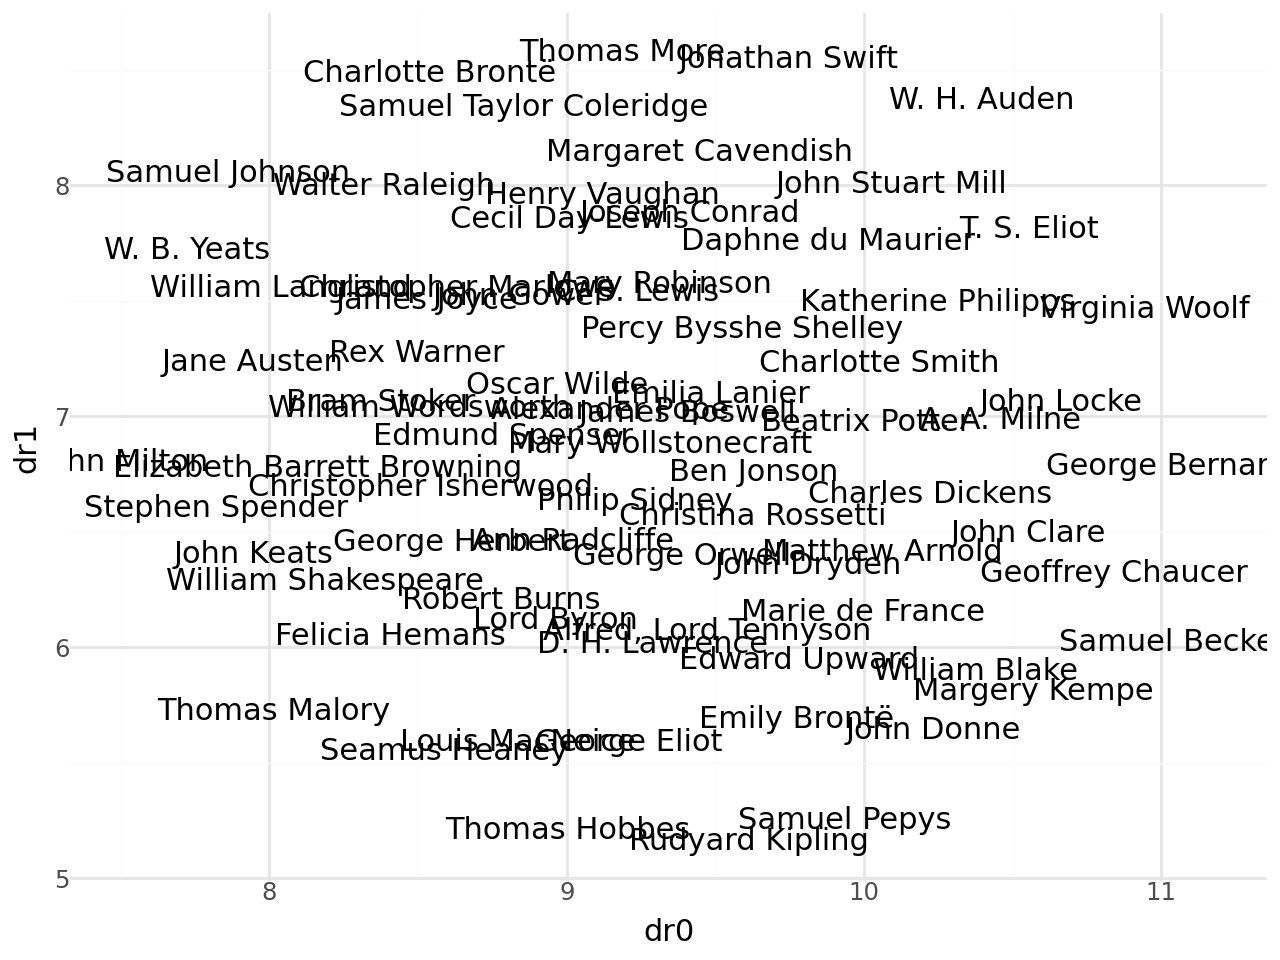

In [12]:
(
    anno
    .filter(c.upos == "NOUN")
    .pipe(
        DSSklearnText.umap,
        doc_id=c.doc_id,
        term_id=c.lemma
    )
    .predict(full=True)
    .pipe(ggplot, aes("dr0", "dr1"))
    + geom_text(aes(label="doc_id"))
)

8. Repeat the UMAP analysis on the same filtered noun annotations, but this time use custom values for `n_neighbors` and `min_dist`. Play around with the values until you get something more interesting that the default.

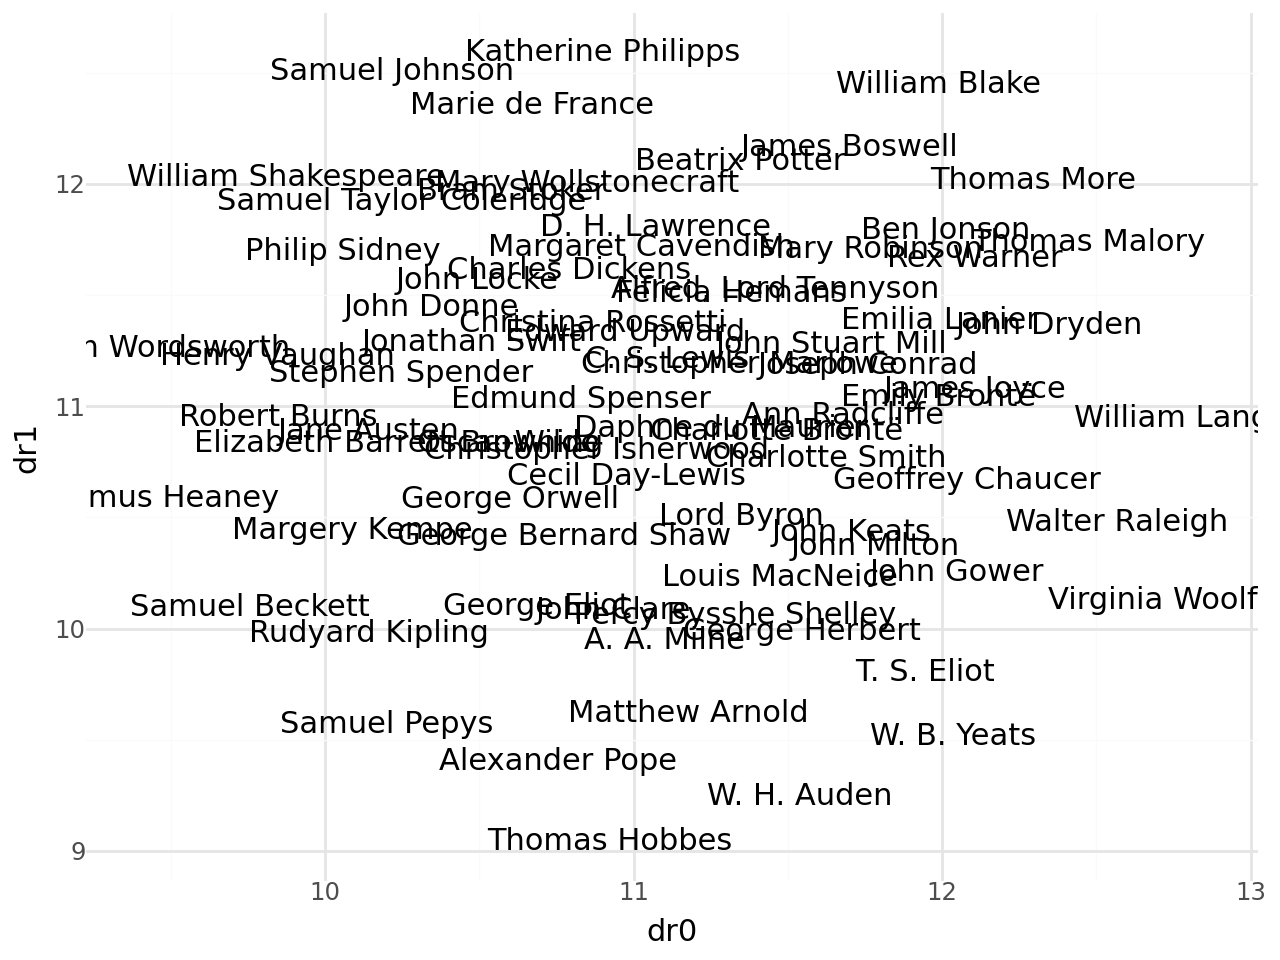

In [13]:
(
    anno
    .filter(c.upos == "NOUN")
    .pipe(
        DSSklearnText.umap,
        doc_id=c.doc_id,
        term_id=c.lemma,
        n_neighbors=5,
        min_dist=0.01
    )
    .predict(full=True)
    .pipe(ggplot, aes("dr0", "dr1"))
    + geom_text(aes(label="doc_id"))
)